In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/comment-category-prediction-challenge/Sample.csv
/kaggle/input/comment-category-prediction-challenge/train.csv
/kaggle/input/comment-category-prediction-challenge/test.csv


# Importing Necessary Libraries

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Loading the Datasets

In [4]:
train_data = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/train.csv")
test_data = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/test.csv")
sample_file = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/Sample.csv")

In [5]:
print("Shape of Training Data",train_data.shape)
print("Shape of Testing Data",test_data.shape)

Shape of Training Data (198000, 15)
Shape of Testing Data (102000, 14)


In [6]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 198000 entries, 0 to 197999
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   created_date  198000 non-null  object
 1   post_id       198000 non-null  int64 
 2   emoticon_1    198000 non-null  int64 
 3   emoticon_2    198000 non-null  int64 
 4   emoticon_3    198000 non-null  int64 
 5   upvote        198000 non-null  int64 
 6   downvote      198000 non-null  int64 
 7   if_1          198000 non-null  int64 
 8   if_2          198000 non-null  int64 
 9   race          52577 non-null   object
 10  religion      52577 non-null   object
 11  gender        52577 non-null   object
 12  disability    198000 non-null  bool  
 13  comment       197999 non-null  object
 14  label         198000 non-null  int64 
dtypes: bool(1), int64(9), object(5)
memory usage: 21.3+ MB


In [7]:
train_data.describe()

,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,label
count,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000
mean,68.447429,0.279768,0.048338,0.121071,2.607975,0.666394,1.906152,7.956212,0.793965
std,27.948390,1.023234,0.258477,0.481013,5.054763,2.044335,25.635752,14.839464,0.979808
min,20.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,0.000000
25%,39.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,0.000000
50%,72.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,6.000000,0.000000
75%,72.000000,0.000000,0.000000,0.000000,3.000000,1.000000,4.000000,10.000000,2.000000
max,129.000000,47.000000,11.000000,17.000000,201.000000,107.000000,1860.000000,1833.000000,3.000000


In [8]:
train_data.head(10)

,created_date,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,religion,gender,disability,comment,label
0,2024-01-18 08:43:57.397508+00:00,73,0,0,0,0,1,0,10,NaN,NaN,NaN,False,She might be a bright spot for a party keou on...,2
1,2024-03-24 21:43:11.490017+00:00,39,0,0,0,6,0,0,4,NaN,NaN,NaN,False,"Under Alaska law, a non-tribal member is not b...",0
2,2024-04-24 20:32:17.014931+00:00,31,0,1,1,0,0,0,10,NaN,NaN,NaN,False,in the future please spare me your strawman dr...,2
3,2023-05-28 22:00:14.214527+00:00,39,0,0,0,5,0,0,10,NaN,NaN,NaN,False,"PS: That should have been ""rot"" instead of ""co...",2
4,2023-09-09 23:12:05.689498+00:00,39,0,0,0,0,0,0,10,NaN,NaN,NaN,False,"Today, the confederate flag...tomorrow, the na...",2
5,2024-04-06 20:10:59.141468+00:00,39,0,0,0,0,0,0,4,NaN,NaN,NaN,False,"Hilarious. Since it wasn't Trump, and that yaw...",0
6,2024-03-04 03:02:55.849172+00:00,72,0,0,0,0,0,0,4,NaN,NaN,NaN,False,Here's an Idea\nState Owned Foreign Companies ...,0
7,2023-10-14 20:57:30.208573+00:00,72,0,0,0,1,1,0,4,NaN,NaN,NaN,False,Victims' participation in the criminla justice...,0
8,2024-02-24 12:13:22.166045+00:00,71,0,0,0,0,0,6,6,none,christian,none,False,I wonder what our ancestors would say when the...,0
9,2023-08-07 20:35:35.968324+00:00,72,1,0,0,6,2,0,4,NaN,NaN,NaN,False,I find it remarkbale that this comment is cons...,0


In [8]:
label_dist = train_data["label"].value_counts(normalize=True)
label_dist

label
0    0.576631
2    0.315354
1    0.080394
3    0.027621
Name: proportion, dtype: float64

In [9]:
num_col = ["upvote", "downvote", "emoticon_1","emoticon_2","emoticon_3"]
train_data[num_col].skew()

upvote         7.102920
downvote      10.062486
emoticon_1     9.980225
emoticon_2     7.557448
emoticon_3     7.060208
dtype: float64

In [10]:
print(train_data.isnull().sum())
print(test_data.isnull().sum())

created_date         0
post_id              0
emoticon_1           0
emoticon_2           0
emoticon_3           0
upvote               0
downvote             0
if_1                 0
if_2                 0
race            145423
religion        145423
gender          145423
disability           0
comment              1
label                0
dtype: int64
created_date        0
post_id             0
emoticon_1          0
emoticon_2          0
emoticon_3          0
upvote              0
downvote            0
if_1                0
if_2                0
race            75269
religion        75269
gender          75269
disability          0
comment             0
dtype: int64


## Exploratory Data Anlysis

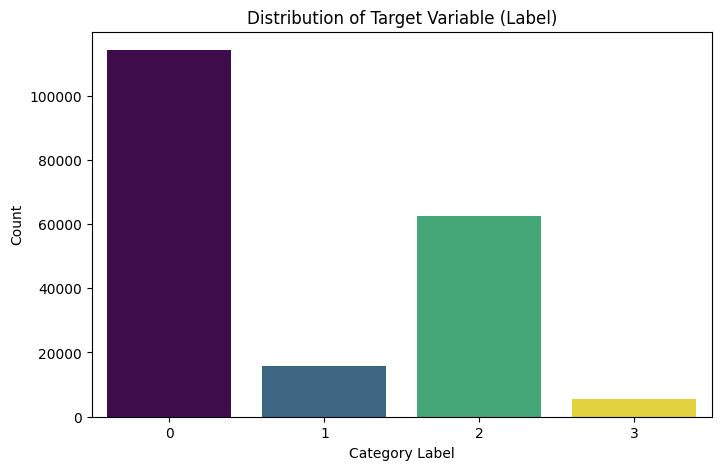

In [11]:
plt.figure(figsize=(8, 5))
sns.countplot(data=train_data, x='label',hue='label', palette='viridis',legend = False)
plt.title('Distribution of Target Variable (Label)')
plt.xlabel('Category Label')
plt.ylabel('Count')
plt.show()

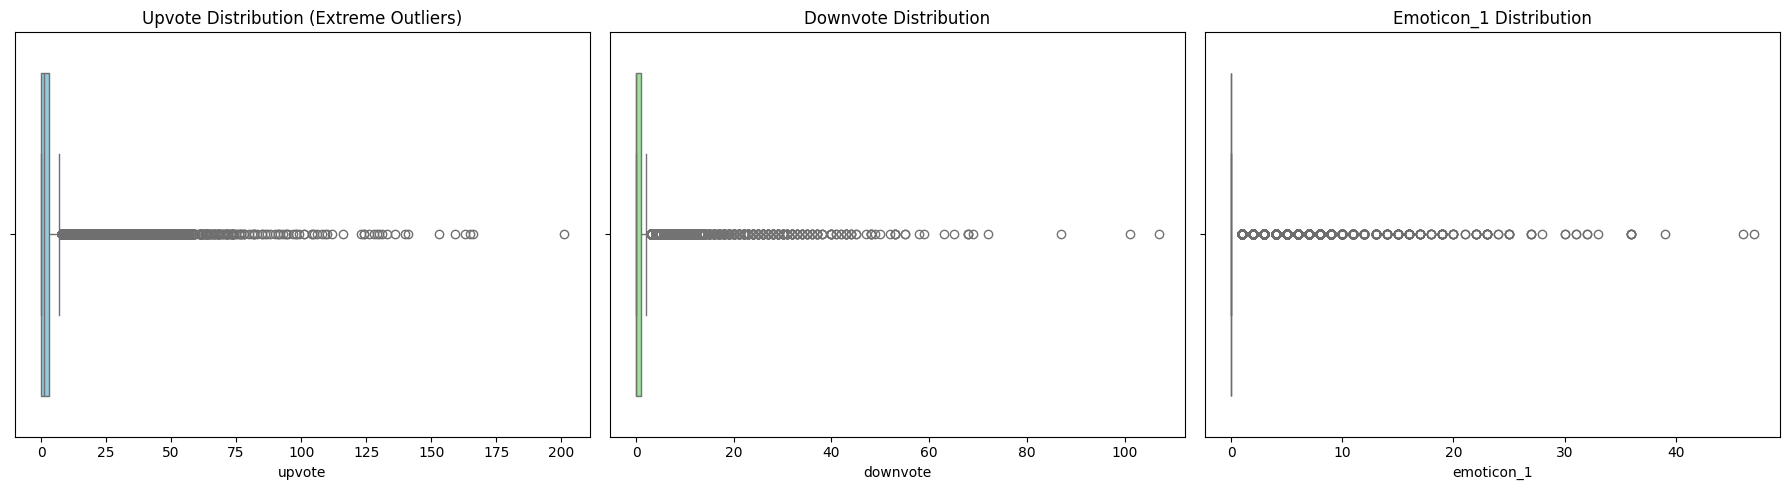

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.boxplot(data=train_data, x='upvote', ax=axes[0], color='skyblue')
axes[0].set_title('Upvote Distribution (Extreme Outliers)')

sns.boxplot(data=train_data, x='downvote', ax=axes[1], color='lightgreen')
axes[1].set_title('Downvote Distribution')

sns.boxplot(data=train_data, x='emoticon_1', ax=axes[2], color='salmon')
axes[2].set_title('Emoticon_1 Distribution')
plt.tight_layout()
plt.show()

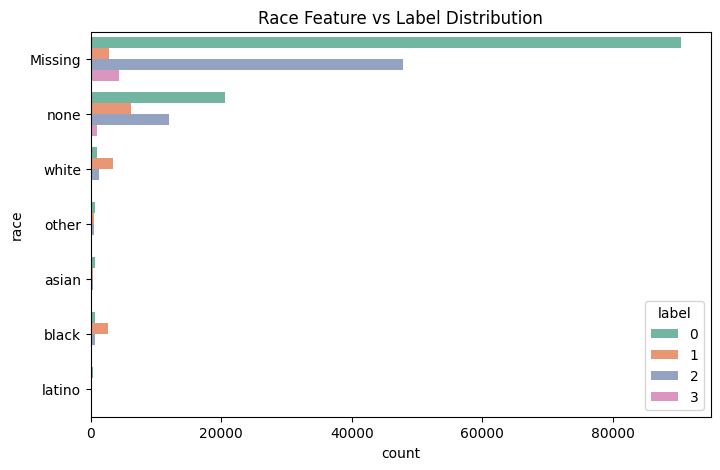

In [13]:
plt.figure(figsize=(8, 5))
temp_race = train_data['race'].fillna('Missing')
sns.countplot(y=temp_race, hue=train_data['label'], palette='Set2')
plt.title('Race Feature vs Label Distribution')
plt.show()

## Findings from the EDA
Based on the exploratory data analysis of the dataset, we can draw several inferences that directly inform our data preprocessing and modeling strategy:

* **Severe Target Class Imbalance:** The target variable (`label`) is highly imbalanced. Class `0` (57.6%) and Class `2` (31.5%) dominate the dataset, while Class `1` (8.0%) and Class `3` (2.7%) are severe minority classes. 
    
* **Extreme Right-Skewness in Numerical Features:** Engagement metrics (`upvote`, `downvote`) and `emoticon_1` exhibit extreme right-skewness (skew > 7) with massive outliers.
    * *This suggests:* Standardizing these features directly with `StandardScaler` would result in distorted feature spaces. We must apply a logarithmic transformation prior to scaling to normalize the distributions and compress the outliers.
* **Meaning of Missing Values:** The categorical demographic flags (`race`, `religion`, `gender`) have over 73% missing values.
    * *This suggests:* Instead of dropping these columns or imputing with the mode, we must fill `NaN` values with a distinct category (e.g., `"blank"` or `"none"`) and apply One-Hot Encoding to treat the absence of a flag as a valid predictive feature.

# Data Cleaning and Feature Engineering

In [14]:

train_data_clean = train_data.copy()
test_data_clean = test_data.copy()

# Handling Missing Categorical Values
categorical_missing_col = ["race", "religion", "gender"]
for column in categorical_missing_col:
    train_data_clean[column] = train_data_clean[column].fillna("blank")
    test_data_clean[column] = test_data_clean[column].fillna("blank")

# Handling Missing Text
train_data_clean['comment'] = train_data_clean['comment'].fillna("")
test_data_clean['comment'] = test_data_clean['comment'].fillna("")

train_data_clean['disability'] = train_data_clean['disability'].astype(int)
test_data_clean['disability'] = test_data_clean['disability'].astype(int)

train_data_clean["created_date"] = pd.to_datetime(train_data_clean["created_date"], errors="coerce")
test_data_clean["created_date"] = pd.to_datetime(test_data_clean["created_date"], errors="coerce")

train_data_clean["hour_posted"] = train_data_clean["created_date"].dt.hour
train_data_clean["day_of_week"] = train_data_clean["created_date"].dt.dayofweek

test_data_clean["hour_posted"] = test_data_clean["created_date"].dt.hour
test_data_clean["day_of_week"] = test_data_clean["created_date"].dt.dayofweek

train_data_clean["comment_len"] = train_data_clean["comment"].astype(str).apply(len)
test_data_clean["comment_len"] = test_data_clean["comment"].astype(str).apply(len)

# Handling Extreme Skewness (Log Transformation)
skewed_cols = ['upvote', 'downvote', 'emoticon_1', 'emoticon_2', 'emoticon_3', 'if_1', 'if_2']
for col in skewed_cols:
    train_data_clean[col] = np.log1p(train_data_clean[col])
    test_data_clean[col] = np.log1p(test_data_clean[col])

# Dropping Colomns that we don't need
train_data_clean = train_data_clean.drop(columns=['created_date', 'post_id'])
test_data_clean = test_data_clean.drop(columns=['created_date', 'post_id'])

x = train_data_clean.drop(columns=["label"])
y = train_data_clean["label"]
x_test = test_data_clean.copy()


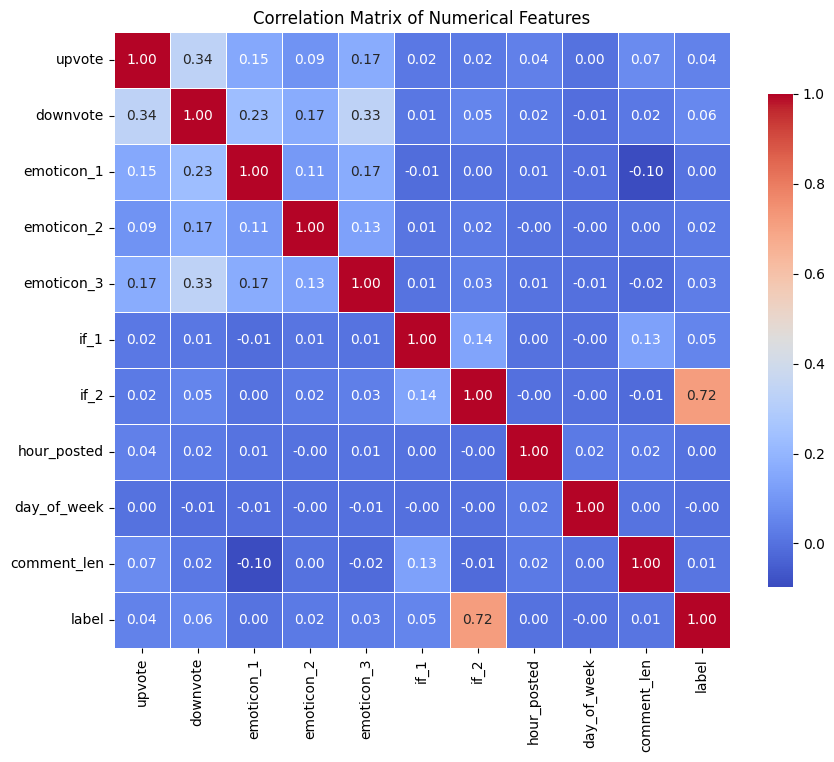

In [15]:
plt.figure(figsize=(10, 8))

num_cols_for_corr = ['upvote', 'downvote', 'emoticon_1', 'emoticon_2', 'emoticon_3', 
                     'if_1', 'if_2', 'hour_posted', 'day_of_week', 'comment_len', 'label']

corr_matrix = train_data_clean[num_cols_for_corr].corr()

sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', square=True, 
            linewidths=0.5, cbar_kws={"shrink": .8})
plt.title('Correlation Matrix of Numerical Features')
plt.show()


/tmp/ipykernel_55/3135400695.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=train_data_clean, x='hour_posted', palette='muted', ax=axes[0])
/tmp/ipykernel_55/3135400695.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=train_data_clean, x='day_of_week', palette='pastel', ax=axes[1])
/tmp/ipykernel_55/3135400695.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])


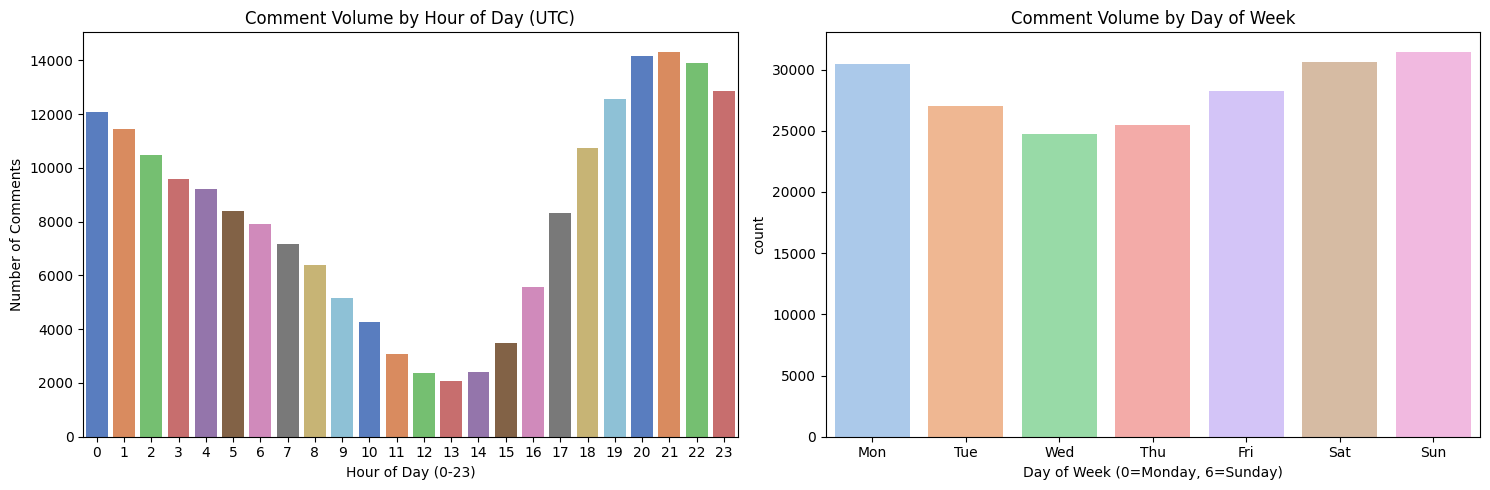

In [16]:

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.countplot(data=train_data_clean, x='hour_posted', palette='muted', ax=axes[0])
axes[0].set_title('Comment Volume by Hour of Day (UTC)')
axes[0].set_xlabel('Hour of Day (0-23)')
axes[0].set_ylabel('Number of Comments')

sns.countplot(data=train_data_clean, x='day_of_week', palette='pastel', ax=axes[1])
axes[1].set_title('Comment Volume by Day of Week')
axes[1].set_xlabel('Day of Week (0=Monday, 6=Sunday)')
axes[1].set_xticklabels(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])

plt.tight_layout()
plt.show()


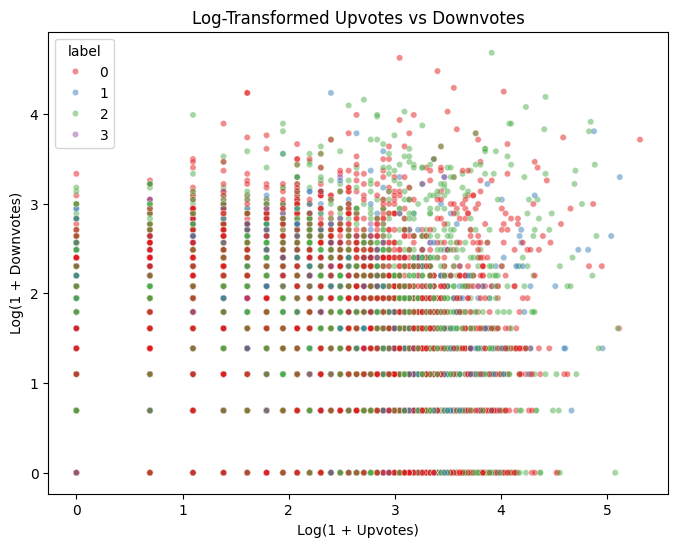

In [17]:

plt.figure(figsize=(8, 6))

sns.scatterplot(data=train_data_clean, x='upvote', y='downvote', hue='label', palette='Set1', alpha=0.5, s=20)
plt.title('Log-Transformed Upvotes vs Downvotes')
plt.xlabel('Log(1 + Upvotes)')
plt.ylabel('Log(1 + Downvotes)')
plt.show()


# Data Splitting

In [18]:

x_train, x_val, y_train, y_val = train_test_split(x, y, test_size=0.3, random_state=42, stratify=y)

print(f"Shape of Training Features: {x_train.shape}")
print(f"Shape of Validation Features: {x_val.shape}")


Shape of Training Features: (138600, 15)
Shape of Validation Features: (59400, 15)


# Preprocessing 

In [19]:

# Defining our feature groups
num_features = ['emoticon_1','emoticon_2', 'emoticon_3', 'upvote', 'downvote', 'if_1', 'if_2', 'hour_posted', 'day_of_week', 'comment_len']
cat_features = ['race', 'religion', 'gender']
pass_features = ['disability'] 

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features),
        
        ('passthrough', 'passthrough', pass_features),
        
        ('text', TfidfVectorizer(lowercase=True, ngram_range=(1,3), max_df=0.2, min_df=3, sublinear_tf=True, max_features=15000), 'comment')
    ],
    n_jobs=-1 
)

x_train_comb = preprocessor.fit_transform(x_train)

x_val_comb = preprocessor.transform(x_val)
x_test_comb = preprocessor.transform(x_test)

print(f" Shape of Processed x_train : {x_train_comb.shape}")
print(f" Shape of Processed x_val : {x_val_comb.shape}")
print(f" Shape of Processed x_test : {x_test_comb.shape}")


 Shape of Processed x_train : (138600, 15033)
 Shape of Processed x_val : (59400, 15033)
 Shape of Processed x_test : (102000, 15033)


# MODEL TRAINING

## Linear SVC 
#### Leaderboard Score: 0.77813

In [20]:

from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, f1_score

print("Support Vector Machine (LinearSVC)")

svm_model = LinearSVC(
    class_weight='balanced', 
    max_iter=2000, 
    random_state=42
)

svm_model.fit(x_train_comb, y_train)

y_val_pred_svm = svm_model.predict(x_val_comb)

svm_macro_f1 = f1_score(y_val, y_val_pred_svm, average='macro')
print(f"LinearSVC Macro F1 Score: {svm_macro_f1:.4f}\n")
print("LinearSVC Classification Report:")
print(classification_report(y_val, y_val_pred_svm))


Support Vector Machine (LinearSVC)
LinearSVC Macro F1 Score: 0.7809

LinearSVC Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.93      0.95     34252
           1       0.69      0.78      0.73      4775
           2       0.85      0.88      0.87     18732
           3       0.54      0.62      0.58      1641

    accuracy                           0.89     59400
   macro avg       0.76      0.80      0.78     59400
weighted avg       0.90      0.89      0.89     59400



## Logistic Regression
#### Leaderboard Score: 0.77623

In [21]:

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, f1_score, confusion_matrix

print("Logistic Regression")

lr_model = LogisticRegression(
    class_weight='balanced', 
    max_iter=1000,          
    random_state=42,
    n_jobs=-1               
)

lr_model.fit(x_train_comb, y_train)

y_val_pred_lr = lr_model.predict(x_val_comb)

lr_macro_f1 = f1_score(y_val, y_val_pred_lr, average='macro')
print(f"Logistic Regression Macro F1 Score: {lr_macro_f1:.4f}\n")
print("Classification Report:")
print(classification_report(y_val, y_val_pred_lr))


Logistic Regression
Logistic Regression Macro F1 Score: 0.7836

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.93      0.95     34252
           1       0.68      0.84      0.75      4775
           2       0.88      0.84      0.86     18732
           3       0.46      0.76      0.57      1641

    accuracy                           0.89     59400
   macro avg       0.75      0.84      0.78     59400
weighted avg       0.91      0.89      0.90     59400



## Stochastic Gradient Descent
#### Leaderboard Score: 0.75701

In [22]:

from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.metrics import classification_report, f1_score, confusion_matrix
print("Stochastic Gradient Descent Classifier")

sgd_model = SGDClassifier(
    loss='log_loss',         
    class_weight='balanced', 
    max_iter=1000,
    random_state=42,
    n_jobs=-1
)

sgd_model.fit(x_train_comb, y_train)

y_val_pred_sgd = sgd_model.predict(x_val_comb)

sgd_macro_f1 = f1_score(y_val, y_val_pred_sgd, average='macro')
print(f"SGD Classifier Macro F1 Score: {sgd_macro_f1:.4f}\n")
print("Classification Report:")
print(classification_report(y_val, y_val_pred_sgd))


Stochastic Gradient Descent Classifier
SGD Classifier Macro F1 Score: 0.7505

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.94      0.95     34252
           1       0.68      0.73      0.71      4775
           2       0.82      0.86      0.84     18732
           3       0.63      0.42      0.50      1641

    accuracy                           0.89     59400
   macro avg       0.77      0.74      0.75     59400
weighted avg       0.89      0.89      0.88     59400



## Multi Layer Perceptron
#### Leaderboard Score: 0.78565

In [23]:

from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, f1_score
import pandas as pd

print("Multi Layer Perceptron")

mlp_model = MLPClassifier(
    hidden_layer_sizes=(256, 128),   
    activation="relu", 
    solver="adam", 
    alpha=0.001,                    
    learning_rate='adaptive',       
    max_iter=100,                   
    early_stopping=True, 
    n_iter_no_change=5,             
    random_state=42
)

mlp_model.fit(x_train_comb, y_train)

y_val_pred_mlp = mlp_model.predict(x_val_comb)

mlp_macro_f1 = f1_score(y_val, y_val_pred_mlp, average='macro')
print(f"Optimized MLP Macro F1 Score: {mlp_macro_f1:.4f}\n")
print("MLP Classification Report:")
print(classification_report(y_val, y_val_pred_mlp))


Multi Layer Perceptron
Optimized MLP Macro F1 Score: 0.7979

MLP Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.94      0.96     34252
           1       0.78      0.74      0.76      4775
           2       0.85      0.89      0.87     18732
           3       0.57      0.66      0.61      1641

    accuracy                           0.90     59400
   macro avg       0.79      0.81      0.80     59400
weighted avg       0.90      0.90      0.90     59400



## XGBoost Classifier
#### Leaderboard Score: 0.76843

In [24]:

from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import classification_report, f1_score
import pandas as pd

print("Boosting Ensemble - XGBoost")

sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)


xgb_model = XGBClassifier(
    objective='multi:softmax',
    num_class=4,
    n_estimators=300,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(x_train_comb, y_train, sample_weight=sample_weights)

y_val_pred_xgb = xgb_model.predict(x_val_comb)

xgb_macro_f1 = f1_score(y_val, y_val_pred_xgb, average='macro')
print(f"XGBoost Macro F1 Score: {xgb_macro_f1:.4f}\n")
print("XGBoost Classification Report:")
print(classification_report(y_val, y_val_pred_xgb))


Boosting Ensemble - XGBoost
XGBoost Macro F1 Score: 0.7670

XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.94      0.96     34252
           1       0.69      0.85      0.76      4775
           2       0.89      0.82      0.85     18732
           3       0.37      0.75      0.50      1641

    accuracy                           0.89     59400
   macro avg       0.73      0.84      0.77     59400
weighted avg       0.91      0.89      0.90     59400



## LightGBM (Hyperparameter Tuning)
#### Leaderboard Score: 0.80787

In [25]:

from sklearn.model_selection import RandomizedSearchCV
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, f1_score
import pandas as pd
import numpy as np

print("Hyperparameter Tuning: LightGBM")

param_distributions = {
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'num_leaves': [31, 50, 80, 120],               
    'min_child_samples': [20, 50, 100],            
    'colsample_bytree': [0.6, 0.8, 1.0],           
    'n_estimators': [200, 300, 400]
}

base_lgbm = LGBMClassifier(
    class_weight='balanced', 
    random_state=42, 
    n_jobs=-1 
)

random_search = RandomizedSearchCV(
    estimator=base_lgbm,
    param_distributions=param_distributions,
    n_iter=10,                                     
    scoring='f1_macro',                            
    cv=3,                                          
    verbose=2,                                     
    random_state=42,
    n_jobs=1 
)

random_search.fit(x_train_comb, y_train)

best_lgbm_model = random_search.best_estimator_

print(random_search.best_params_)

y_val_pred_best = best_lgbm_model.predict(x_val_comb)

best_macro_f1 = f1_score(y_val, y_val_pred_best, average='macro')
print(f"\nTuned LightGBM Macro F1 Score: {best_macro_f1:.4f}\n")
print("Tuned LightGBM Classification Report:")
print(classification_report(y_val, y_val_pred_best))


Hyperparameter Tuning: LightGBM
Fitting 3 folds for each of 10 candidates, totalling 30 fits
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 5.262696 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 812013
[LightGBM] [Info] Number of data points in the train set: 92400, number of used features: 8413
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END colsample_bytree=1.0, learning_rate=0.2, min_child_samples=100, n_estimators=300, num_leaves=31; total time= 4.7min
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 5.170688 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 804372
[LightGBM] [Info] Number of data points in the train set: 92400, number of used features: 8334
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END colsample_bytree=1.0, learning_rate=0.2, min_child_samples=100, n_estimators=300, num_leaves=31; total time= 4.6min
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 5.204859 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 812286
[LightGBM] [Info] Number of data points in the train set: 92400, number of used features: 8447
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294


...

[CV] END colsample_bytree=0.8, learning_rate=0.01, min_child_samples=20, n_estimators=300, num_leaves=31; total time= 6.7min
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 8.492202 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 982040
[LightGBM] [Info] Number of data points in the train set: 92400, number of used features: 15032
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[CV] END colsample_bytree=0.8, learning_rate=0.01, min_child_samples=20, n_estimators=300, num_leaves=31; total time= 6.7min
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 12.396991 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1318724
[LightGBM] [Info] Number of data points in the train set: 138600, number of used features: 15033
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
{'num_leaves': 120, 'n_estimators': 200, 'min_child_samples': 20, 'learning_rate': 0.1, 'colsample_bytree': 0.6}


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



Tuned LightGBM Macro F1 Score: 0.8168

Tuned LightGBM Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.94      0.96     34252
           1       0.73      0.83      0.78      4775
           2       0.87      0.89      0.88     18732
           3       0.62      0.67      0.64      1641

    accuracy                           0.91     59400
   macro avg       0.80      0.84      0.82     59400
weighted avg       0.92      0.91      0.91     59400



## Weighted Ensemble - Multi Layer Perceptron and LightGBM
Just changing the weights assigned to our previous ensemble

#### Leaderboard Score: 0.81292



In [26]:

from sklearn.ensemble import VotingClassifier
from sklearn.metrics import f1_score, classification_report
import pandas as pd


estimators_weighted = [
    ('Tuned_LightGBM', best_lgbm_model),
    ('Optimized_MLP', mlp_model)
]

weighted_ensemble = VotingClassifier(
    estimators=estimators_weighted,
    voting='soft',
    weights=[2, 1], 
    n_jobs=1 
)

weighted_ensemble.fit(x_train_comb, y_train)

y_val_pred_weight = weighted_ensemble.predict(x_val_comb)
weighted_macro_f1 = f1_score(y_val, y_val_pred_weight, average='macro')

print(f"\n Weighted Ensemble Validation Macro F1 Score: {weighted_macro_f1:.6f}\n")
print("Ensemble Classification Report:")
print(classification_report(y_val, y_val_pred_weight))


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 12.631702 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1318724
[LightGBM] [Info] Number of data points in the train set: 138600, number of used features: 15033
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



 Weighted Ensemble Validation Macro F1 Score: 0.821145

Ensemble Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.95      0.96     34252
           1       0.75      0.82      0.78      4775
           2       0.87      0.90      0.88     18732
           3       0.64      0.68      0.66      1641

    accuracy                           0.91     59400
   macro avg       0.81      0.83      0.82     59400
weighted avg       0.92      0.91      0.91     59400



# Submission

In [27]:

submission_df = sample_file.copy()
submission_df['label'] = weighted_ensemble.predict(x_test_comb)

submission_df.to_csv('submission.csv', index=False)
print("Success! 'submission.csv' has been generated.")


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Success! 'submission.csv' has been generated.


# Score Comparison of Different Models

In [28]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("--- FINAL MODEL LEADERBOARD ---\n")

model_names = [
    'Linear SVC', 
    'Logistic Regression',
    'Stochastic Gradient Descent', 
    'Multi Layer Perceptron',
    'XGBoost', 
    'Tuned LightGBM',
    'Weighted Ensemble - TunedLightGBM and Multi Layer Perceptron'
]

f1_scores = [
    0.77813,
    0.77623,
    0.75701,
    0.78565,
    0.76843,
    0.80787,
    0.81292
]

summary_df = pd.DataFrame({
    'Model Architecture': model_names,
    'Validation Macro F1 Score': f1_scores
})

summary_df = summary_df.sort_values(by='Validation Macro F1 Score', ascending=False).reset_index(drop=True)


def highlight_top_3(row):
    if row.name < 3:
        return ['background-color: #d4edda; color: black; font-weight: bold'] * len(row)
    else:
        return [''] * len(row)

styled_table = summary_df.style.apply(highlight_top_3, axis=1)
display(styled_table)


--- FINAL MODEL LEADERBOARD ---



,Model Architecture,Validation Macro F1 Score
0,Weighted Ensemble - TunedLightGBM and Multi Layer Perceptron,0.812920
1,Tuned LightGBM,0.807870
2,Multi Layer Perceptron,0.785650
3,Linear SVC,0.778130
4,Logistic Regression,0.776230
5,XGBoost,0.768430
6,Stochastic Gradient Descent,0.757010
